In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
with open ('cardiovascular_diseases.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim      Dim1             Value  NumericValue  \
0                NaN        EUR   SEX_MLE  43.8 [41.5-46.1]     43.838024   
1                NaN      WB_HI  SEX_FMLE  23.6 [22.6-24.6]     23.569540   
2                AMR        CRI  SEX_BTSX  19.2 [13.1-25.7]     19.212719   
3                EUR        KGZ  SEX_FMLE  36.5 [29.7-43.8]     36.537498   
4                NaN     WB_LMI  SEX_BTSX  29.1 [27.2-31.0]     29.082129   

                            Date IndicatorCode  
0  2024-04-29T15:59:45.237+02:00         BP_03  
1  2024-04-29T15:59:45.237+02:00         BP_03  
2  2024-04-29T15:59:45.237+02:00         BP_03  
3  2024-04-29T15:59:45.237+02:00         BP_03  
4  2024-04-29T15:59:45.237+02:00         BP_03  


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 236876 entries, 0 to 236875
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ParentLocationCode  220408 non-null  str    
 1   SpatialDim          236876 non-null  str    
 2   Dim1                232414 non-null  str    
 3   Value               236876 non-null  str    
 4   NumericValue        231306 non-null  float64
 5   Date                236876 non-null  str    
 6   IndicatorCode       236876 non-null  str    
dtypes: float64(1), str(6)
memory usage: 12.7 MB


,NumericValue
count,231306.000000
mean,44.590119
std,77.295660
min,0.500000
25%,20.900000
50%,33.300000
75%,46.200000
max,5736.000000


In [4]:
df['NumericValue'].isnull().sum()

np.int64(5570)

In [5]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

236876
231306
0


In [6]:
# #remove indicators that not relevant
# unrelated = set(['NCD_GLUC_01', 'NCD_GLUC_02', 'NCD_GLUC_03', 'NCD_GLUC_04', 'SA_0000001421','SA_0000001440'])
# df = df[~df['IndicatorCode'].isin(unrelated)]

In [7]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['BP_03', 'BP_04', 'BP_05', 'BP_06', 'NCDMORT3070', 'NCD_HYP_CONTROL_A', 'NCD_HYP_CONTROL_C', 'NCD_HYP_DIAGNOSIS_A', 'NCD_HYP_DIAGNOSIS_C', 'NCD_HYP_PREVALENCE_A', 'NCD_HYP_PREVALENCE_C', 'NCD_HYP_TREATMENT_A', 'NCD_HYP_TREATMENT_C', 'SA_0000001425', 'SA_0000001444']


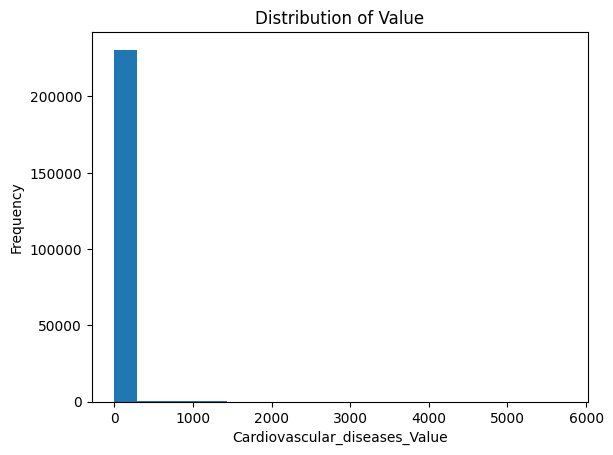

In [8]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("Cardiovascular_diseases_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


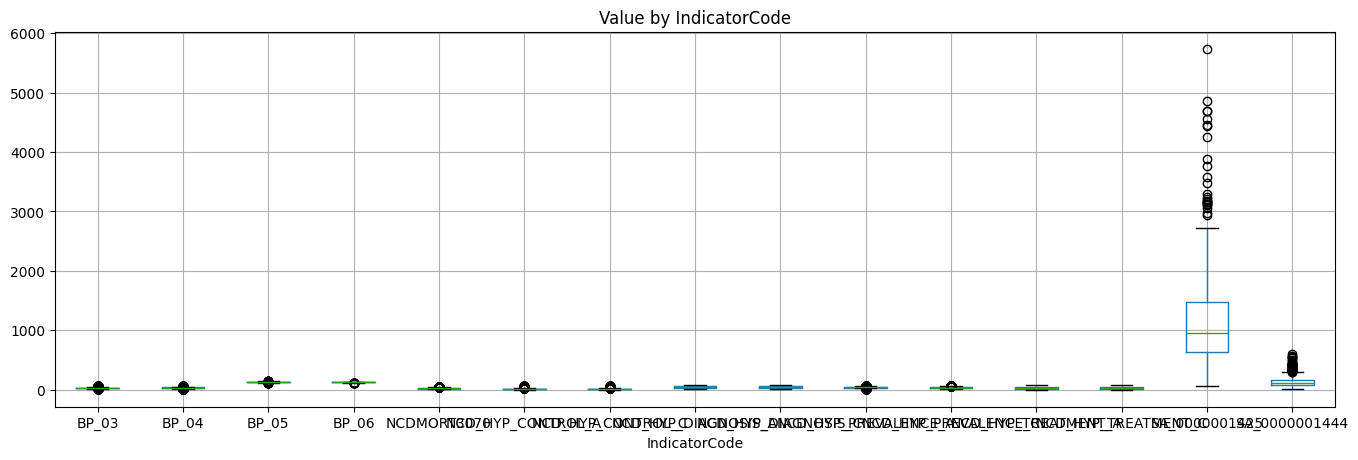

In [9]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()